In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Load dataset
df = pd.read_csv("/kaggle/input/amazon-employee-access-challenge/train.csv")

# Check data
df.head()



,ACTION,RESOURCE,MGR_ID,ROLE_ROLLUP_1,ROLE_ROLLUP_2,ROLE_DEPTNAME,ROLE_TITLE,ROLE_FAMILY_DESC,ROLE_FAMILY,ROLE_CODE
0,1,39353,85475,117961,118300,123472,117905,117906,290919,117908
1,1,17183,1540,117961,118343,123125,118536,118536,308574,118539
2,1,36724,14457,118219,118220,117884,117879,267952,19721,117880
3,1,36135,5396,117961,118343,119993,118321,240983,290919,118322
4,1,42680,5905,117929,117930,119569,119323,123932,19793,119325


In [3]:
# Dataset shape
print("Dataset Shape (Rows, Columns):", df.shape)

# Column names
print("\nColumns in Dataset:\n", df.columns)

# Dataset information
print("\nDataset Info:")
df.info()


Dataset Shape (Rows, Columns): (32769, 10)

Columns in Dataset:
 Index(['ACTION', 'RESOURCE', 'MGR_ID', 'ROLE_ROLLUP_1', 'ROLE_ROLLUP_2',
       'ROLE_DEPTNAME', 'ROLE_TITLE', 'ROLE_FAMILY_DESC', 'ROLE_FAMILY',
       'ROLE_CODE'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32769 entries, 0 to 32768
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   ACTION            32769 non-null  int64
 1   RESOURCE          32769 non-null  int64
 2   MGR_ID            32769 non-null  int64
 3   ROLE_ROLLUP_1     32769 non-null  int64
 4   ROLE_ROLLUP_2     32769 non-null  int64
 5   ROLE_DEPTNAME     32769 non-null  int64
 6   ROLE_TITLE        32769 non-null  int64
 7   ROLE_FAMILY_DESC  32769 non-null  int64
 8   ROLE_FAMILY       32769 non-null  int64
 9   ROLE_CODE         32769 non-null  int64
dtypes: int64(10)
memory usage: 2.5 MB


In [4]:
# Count of access granted vs denied
df['ACTION'].value_counts()


ACTION
1    30872
0     1897
Name: count, dtype: int64

In [5]:
# Percentage distribution
(df['ACTION'].value_counts(normalize=True) * 100)


ACTION
1    94.210992
0     5.789008
Name: proportion, dtype: float64

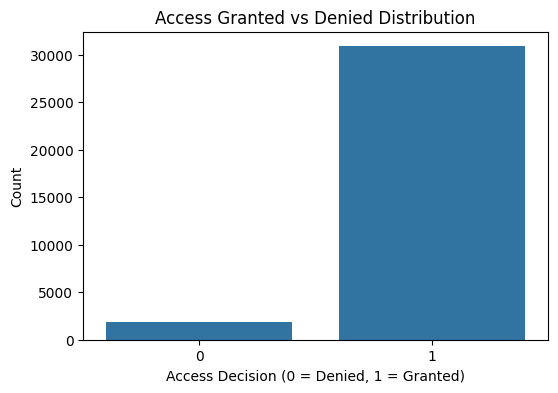

In [6]:
plt.figure(figsize=(6,4))
sns.countplot(x='ACTION', data=df)
plt.title("Access Granted vs Denied Distribution")
plt.xlabel("Access Decision (0 = Denied, 1 = Granted)")
plt.ylabel("Count")
plt.show()


In [7]:
# Separate features and target
X = df.drop("ACTION", axis=1)
y = df["ACTION"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)


# Train-test split (Stratified because dataset is imbalanced)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)


Feature Shape: (32769, 9)
Target Shape: (32769,)
Training Data Shape: (26215, 9)
Testing Data Shape: (6554, 9)


In [8]:
# Install category encoders (Kaggle usually has it, but safe to include)
!pip install category_encoders


In [9]:
from category_encoders import TargetEncoder

# Apply Target Encoding
encoder = TargetEncoder(cols=X_train.columns)

X_train_enc = encoder.fit_transform(X_train, y_train)
X_test_enc = encoder.transform(X_test)

print("Encoded Training Shape:", X_train_enc.shape)
print("Encoded Testing Shape:", X_test_enc.shape)


Encoded Training Shape: (26215, 9)
Encoded Testing Shape: (6554, 9)


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# Create Logistic Regression model
lr_model = LogisticRegression(max_iter=1000)

# Train the model
lr_model.fit(X_train_enc, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test_enc)
y_prob_lr = lr_model.predict_proba(X_test_enc)[:, 1]

# Evaluation
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("ROC AUC Score:", roc_auc_score(y_test, y_prob_lr))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))


Logistic Regression Accuracy: 0.9404943545926152
ROC AUC Score: 0.8411940649268798

Classification Report:

              precision    recall  f1-score   support

           0       0.46      0.16      0.23       379
           1       0.95      0.99      0.97      6175

    accuracy                           0.94      6554
   macro avg       0.70      0.57      0.60      6554
weighted avg       0.92      0.94      0.93      6554



In [11]:
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

# Train the model
rf_model.fit(X_train_enc, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test_enc)
y_prob_rf = rf_model.predict_proba(X_test_enc)[:, 1]

# Evaluation
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("ROC AUC Score:", roc_auc_score(y_test, y_prob_rf))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.938358254501068
ROC AUC Score: 0.8135156441947164

Classification Report:

              precision    recall  f1-score   support

           0       0.44      0.22      0.29       379
           1       0.95      0.98      0.97      6175

    accuracy                           0.94      6554
   macro avg       0.69      0.60      0.63      6554
weighted avg       0.92      0.94      0.93      6554



In [12]:
from sklearn.linear_model import LogisticRegression

# Balanced Logistic Regression
balanced_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

# Train balanced model
balanced_model.fit(X_train_enc, y_train)

# Predictions
y_pred_bal = balanced_model.predict(X_test_enc)
y_prob_bal = balanced_model.predict_proba(X_test_enc)[:, 1]

# Evaluation
print("Balanced Logistic Accuracy:", accuracy_score(y_test, y_pred_bal))
print("Balanced ROC AUC:", roc_auc_score(y_test, y_prob_bal))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_bal))


Balanced Logistic Accuracy: 0.8875495880378395
Balanced ROC AUC: 0.8390174441583969

Classification Report:

              precision    recall  f1-score   support

           0       0.27      0.57      0.37       379
           1       0.97      0.91      0.94      6175

    accuracy                           0.89      6554
   macro avg       0.62      0.74      0.65      6554
weighted avg       0.93      0.89      0.91      6554



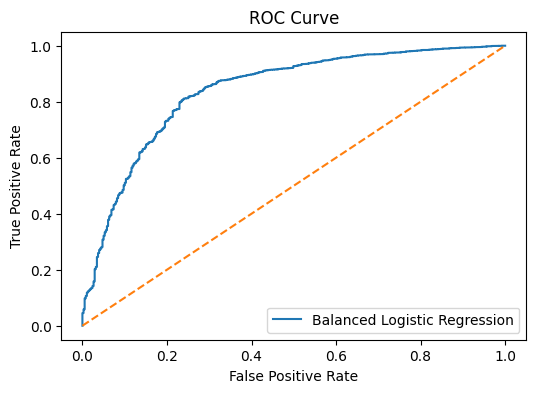

In [13]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_bal)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label="Balanced Logistic Regression")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


In [14]:
import joblib

# Save trained model
joblib.dump(balanced_model, "amazon_access_model.pkl")

# Save encoder
joblib.dump(encoder, "target_encoder.pkl")

print("Model and Encoder Saved Successfully")


Model and Encoder Saved Successfully


In [17]:
# Predict using balanced model
y_pred_bal = balanced_model.predict(X_test_enc)
y_prob_bal = balanced_model.predict_proba(X_test_enc)[:,1]


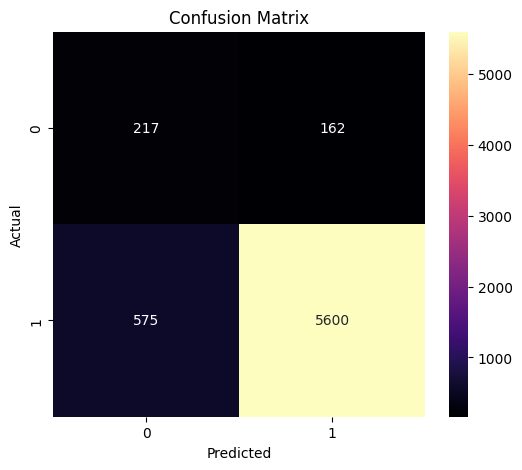

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_bal)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='magma')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


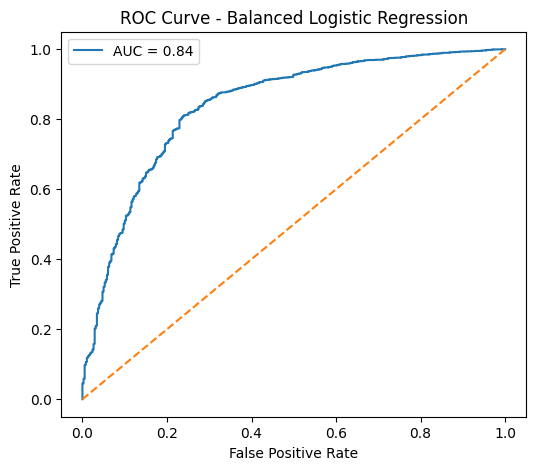

In [19]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob_bal)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Balanced Logistic Regression")
plt.legend()
plt.show()


In [20]:
import joblib

joblib.dump(balanced_model, "amazon_access_model.pkl")
joblib.dump(encoder, "target_encoder.pkl")

print("Model and Encoder Saved Successfully")


Model and Encoder Saved Successfully
